#### This notebook plots a chosen random graph with clustering analysis

In [1]:
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx

import cnetwork

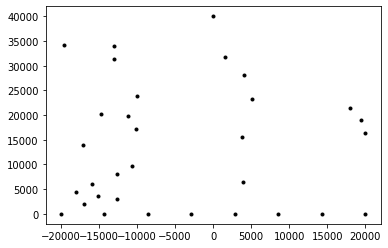

In [2]:
x_scale = 40e3
z_scale = 40e3
mass_in_rate = 10.0 # kg / s

# Load geometry
loaded = np.load("graph_coordinates.npz")
plt.plot(loaded["x_coords"], loaded["z_coords"], 'k.')
N_chamber = len(loaded["x_coords"])


In [3]:
# Set default properties--these are what each magma chamber takes as default if
# properties are not individually specified for each chamber.

dpdx_crit = 5e2
# dpdx_crit = 5e2 # Use with default N_r = 50
# dpdx_crit = 20e2 # Use with N_r = 10 schematic

crust_props = cnetwork.default_props(
  t_b_default = 1e17,           # Maxwell / relaxation time (in isotropic strain) (Pa)
  t_d_default = 5e12,         # Maxwell / relaxation time (in deviatoric strain) (Pa)
  K_crust_default = 10e9,     # Bulk modulus of crust (Pa)
  G_crust_default = 10e9,     # Shear modulus of crust (Pa)
  K_f_default = 10e9,         # Bulk modulus of fluid / melt (Pa)
  r_hydr_default = 5,        # Hydraulic radius of channels / dikes (m)
  mu_default = 1e6,           # Melt viscosity in crust, constant (Pa s)
)

other_props = dict(
  R_min = 500,                # Minimum radius of magma chamber for random generation (m)
  R_max = 500,                # Maximum radius of magma chamber for random generation (m)
  N_chamber = N_chamber,             # Number of chambers to generate
  x_scale = x_scale,             # Length scale of horizontal (x) direction (m)
  z_scale = z_scale,             # Length scale of horizontal (x) direction (m)
  mass_in_rate = mass_in_rate,         # Input mass rate at bottom node (kg / s)
  p_erupt = 5e6,              # Overpressure required for eruption at top node (Pa)
  dpdx_crit = dpdx_crit,            # Minimum pressure gradient for opening dike (Pa / m)
  dpdx_threshold_scale = 0.0, # Numerical smoothing parameter for dpdx_crit (Pa / m)
  # Eruption parameters (the erupting conduit is treated differently from dikes between chambers)
  mu_erupt = 1e5,             # Melt viscosity in erupting conduit (Pa s)
  # r_conduit_erupt = 25,       # Conduit radius for erupting conduit (m)
  r_conduit_erupt = 50,       # Conduit radius for erupting conduit (m)
  rhoref = 2500,              # Reference density of fluid / melt (Pa)
)

numerics = cnetwork.default_numerics()
numerics["Nr"] = 40 # Prod: 40; draft: 20
numerics

{'Nr': 40, 'R_outer_ratio': 20}

In [4]:
# Unpack the props dictionary
t_b = crust_props["t_b_default"]
t_d = crust_props["t_d_default"]
K_crust = crust_props["K_crust_default"]
G_crust = crust_props["G_crust_default"]
K_f = crust_props["K_f_default"]
r_hydr = crust_props["r_hydr_default"]
mu0 = crust_props["mu_default"]

R_min = other_props["R_min"]
R_max = other_props["R_max"]
N_chamber = other_props["N_chamber"]
x_scale = other_props["x_scale"]
z_scale = other_props["z_scale"]
rhoref = other_props["rhoref"]

# Uniformly randomly distribution volume
V_min = (4/3)*np.pi*R_min**3
V_max = (4/3)*np.pi*R_max**3
# List generation of chamber characteristics
x_nodes = loaded["x_coords"]
y_nodes = 0.0 * loaded["x_coords"]
z_nodes = loaded["z_coords"] - z_scale

# Generate random magma chamber size (if R_max == R_min, no randomness)
V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

# Generate list of MagmaChamber nodes, which store the volume, mass, energy in chamber
list_nodes = [cnetwork.MagmaChamber(x=x, y=y, z=z,
  p_setting=None, vref=1.0/rhoref,
  T_setting=1000+273.15, V_setting=V)
  for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

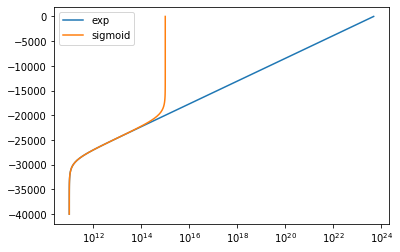

In [5]:
''' Set node viscosity '''

def t_d_curve(z, mode=1):
  z_center = -20000
  z_scale = 1000
  a_min = 1e11
  a_max = 1e15
  if mode == 0:
    # Exponential decay
    val = a_min + (a_max - a_min) * np.exp((z - z_center)/z_scale)
  elif mode == 1:
    # Tanh
    val = a_min + 0.5 * (a_max - a_min) * (1 + np.tanh(0.5 * (z - z_center)/z_scale))
  
  return val

z_plot = np.linspace(z_nodes.min(), z_nodes.max(), 100)

plt.semilogx(t_d_curve(z_plot, mode=0), z_plot, label="exp")
plt.semilogx(t_d_curve(z_plot, mode=1), z_plot, label="sigmoid")
plt.legend()

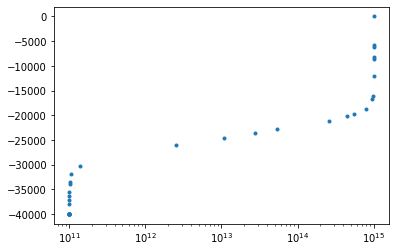

In [6]:
# Append viscosity (Maxwell time)
for node in list_nodes:
  # Elastic crust
  # node.t_d = t_d_curve(0.0, mode=1)
  # Sigmoidal relaxation time
  node.t_d = t_d_curve(node.z, mode=1)
  # Relaxation assumption (Qkappa/Qmu ~ 1)
  # node.t_b = node.t_d
  node.t_b = 1e16

plt.semilogx([node.t_d for node in list_nodes], [node.z for node in list_nodes], '.')

In [7]:
# Set up main system for timestepping later
global_sys = cnetwork.GlobalSystemThreshold(list_nodes, **crust_props,
  **numerics, dpdx_crit=other_props["dpdx_crit"],
  dpdx_threshold_scale=other_props["dpdx_threshold_scale"],
  max_edge_dist=np.inf)

In [8]:
# Time vector setting

# Pre-production settings
_prod = True

if _prod:
  t_final = 2e12
  t_vec = np.linspace(0, t_final, 60000)
else:
  t_final = 1e13
  ''' Underresolved elastic '''
  t_vec = np.linspace(0, t_final, 20000) # pre-prod
  ''' Elastic 1 '''
  t_vec = np.linspace(0, t_final, 100000) # prod [~45 min; 2hr total]
  ''' Elastic 2 '''
  t_vec = np.linspace(0, t_final, 300000) # prod good

dt = t_vec[1] - t_vec[0]
N_t = len(t_vec)

In [9]:
f_erupt = global_sys.create_eruptible_layer(
  z_min=-z_scale*0.001,
  z_max=0.0,
  p_erupt_min=other_props["p_erupt"],
  p_erupt_max=other_props["p_erupt"],
  mu_erupt=other_props["mu_erupt"],
  r_conduit=other_props["r_conduit_erupt"])
f_inj = global_sys.create_mass_injection_layer(
  fn_z=None,
  mdot_inj = other_props["mass_in_rate"] / N_chamber,
  z_max=-z_scale+.001,)

In [10]:
# Time-dependent simulation
q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)
m_hist, p, u = global_sys.compute_m_p_u(q_out)

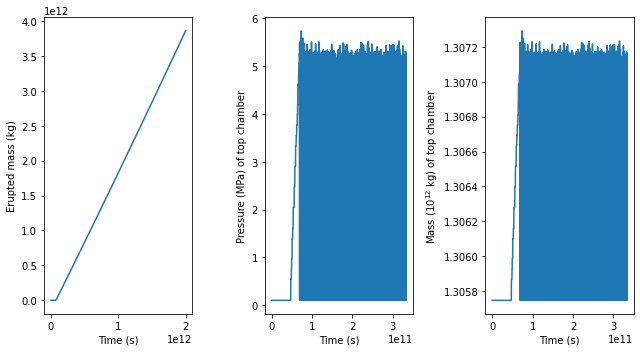

In [11]:
plt.figure(figsize=(9,5))

plt.subplot(1,3,1)
plt.plot(t_vec, m_erupted_out)
plt.xlabel("Time (s)")
plt.ylabel("Erupted mass (kg)")

plt.subplot(1,3,2)
plt.plot(t_vec[:10000], p[:10000,-1] / 1e6)
plt.xlabel("Time (s)")
plt.ylabel("Pressure (MPa) of top chamber")

plt.subplot(1,3,3)
plt.plot(t_vec[:10000], m_hist[:10000,-1] / 1e12)
plt.xlabel("Time (s)")
plt.ylabel("Mass ($10^{12}$ kg) of top chamber")

plt.tight_layout()

In [12]:
# Calculate connectivity matrix at each time, then take average
Y_avg = global_sys.compute_time_averaged_connectivity_matrix(
  t_vec, q_out, averaged=True)

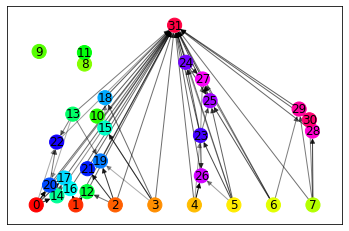

In [13]:
# Plot options
node_scale=200
plot_threshold=0.0
with_labels = True
arrows=True
length_scale = 1e3

# Only plot for edge weights larger than plot_threshold
Y_avg = np.where(Y_avg / Y_avg.max() > plot_threshold, Y_avg, 0.0)

# Construct directed graph
G = nx.DiGraph(Y_avg)

pos = {i:(n.x / length_scale, n.z / length_scale,)
        for (i, n) in enumerate(global_sys.nodes)}
V_nodes = np.array([node.V for node in global_sys.nodes])
# Set node appearance
node_size = node_scale*V_nodes/V_nodes.max()
node_colors =  matplotlib.cm.hsv(
  np.linspace(0,1,global_sys.num_blocks,endpoint=False))
# Take averaged conductivity Y as edge intensity
edge_intensity = (np.array(scipy.sparse.csr_matrix(Y_avg).data))
edge_intensity /= edge_intensity.max()

# Create new colormap
from matplotlib.colors import ListedColormap
custom_cmap_array = np.zeros((256,4))
custom_cmap_array[:,3] = np.linspace(0, 1 ,256)**0.2
custom_cmap = ListedColormap(custom_cmap_array)

nx.draw_networkx(G, pos,
                node_size=node_size,
                node_color=node_colors,
                edge_cmap=custom_cmap,
                # edge_cmap=matplotlib.cm.Greys,
                edge_color=edge_intensity, with_labels=with_labels, arrows=arrows)


In [101]:
window_nodes_vec=[1, 10, 100]
num_inj=8

def compute_resistance_st(Y_avg, num_inj):
  G = nx.Graph(Y_avg)

  st_conductance = 0
  for i in range(num_inj):
    ''' For all injection sites, find a path to the out '''
    if not nx.has_path(G, i, global_sys.num_blocks-1):
      continue
    # Construct s-t test vector
    chi = np.zeros(Y_avg.shape[0],)
    chi[[i, -1]] = [1.0, -1.0]
    # Compute effective conductivity using conjugate gradient for PSD matrix
    v, exit_code = scipy.sparse.linalg.cg(nx.laplacian_matrix(G), chi)
    if exit_code != 0:
      raise ValueError(f"scipy.sparse.linalg.cg terminated with unsuccessful exit code {exit_code}.")
    st_conductance += 1.0 / np.dot(chi, v) / num_inj
    # Save effective conductivity at time t to output vector
  return st_conductance


In [ ]:
# Compute Y(t)
Y_list = [None for _ in range(q_out.shape[0])]
for i in range(q_out.shape[0]):
  # Get instantaneous, asymmetric connectivity matrix of graph
  Y_native = global_sys.get_connectivity(q_out[i,:])
  # Symmetrized connectivity
  Y_list[i] = scipy.sparse.csr_matrix(np.maximum(Y_native, Y_native.T))


In [102]:

all_effective_conductivities = []
for n in window_nodes_vec:
  # From t_vec compute array of window-center times
  if n == 1:
    t_avg_range = t_vec
  else:
    t_avg_range = 0.5 * (t_vec[:-n+1] + t_vec[n-1:]) 
  # Compute window size
  dt_window = n * (t_vec[1] - t_vec[0])

  # Allocate output for current window size
  effective_cond = np.zeros_like(t_avg_range, dtype=float)

  for i in range(t_vec.size - n + 1):
    # Time-averaged connectivity
    Y_avg = np.sum(np.abs(Y_list[i:i+n])) / n
    if Y_avg.nnz == 0:
      # No edges, zero connectivity 
      continue

    effective_cond[i] = compute_resistance_st(Y_avg, num_inj)
    

  all_effective_conductivities.append((n, dt_window, t_avg_range, effective_cond))

In [32]:
i

2105

In [37]:
i = 1237
Y_avg = np.sum(np.abs(Y_list[i:i+n])) / n
Y_avg.nnz

68

In [38]:
G = nx.Graph(Y_avg)
nx.has_path(G, 0, global_sys.num_blocks-1)

False

In [68]:
chi = np.zeros(Y_avg.shape[0],)
if num_inj == 1:
  chi[[0, -1]] = [1.0, -1.0]
else:
  chi[np.arange(0, 1)] = 1.0/num_inj
  chi[-1] = -1.0/num_inj
# Compute effective conductivity using conjugate gradient for PSD matrix
v, exit_code = scipy.sparse.linalg.cg(nx.laplacian_matrix(G), chi)

In [90]:
out = scipy.sparse.linalg.lsmr(scipy.sparse.csgraph.laplacian(Y_avg), chi)

In [72]:
np.dot(chi, out[0])

167723225.07829836

In [20]:
nx.laplacian_matrix(G)

<32x32 sparse array of type '<class 'numpy.float64'>'
	with 112 stored elements in Compressed Sparse Row format>

In [14]:
'''

Unpack the output: n is the time-averaging window size used (in this case just 1)
  dt_window: the timestep over which averaging happens (in this case just the simulation timestep dt)
  t_avg_range: window-averaged time vector (in this case just t_vec)
  effective_cond: effective hydraulic conductivity at each time t '''

connectivity_output = global_sys.compute_effective_connectivity(t_vec, q_out, window_nodes_vec=[1, 10, 100], num_inj=8)

n, dt_window, t_avg_range, effective_cond = connectivity_output[0]

ValueError: scipy.sparse.linalg.cg terminated with unsuccessful exit code 320.

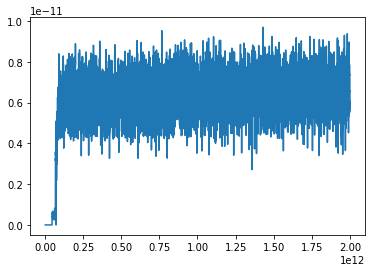

In [105]:
n, dt_window, t_avg_range, effective_cond = connectivity_output[2]
plt.plot(t_avg_range, effective_cond)

Big figure

In [114]:
Y_all = global_sys.compute_time_averaged_connectivity_matrix(
  t_vec, q_out, averaged=False)

In [115]:
'''
Sampling at uniformly spaced z-levels
See also cnetwork.py::sample_mass_rate_z
'''

z_samples = 400

# # Downsample q_out
q_work = q_out[::,:]
# t_work = t_vec[::]

# # Compute sampling mesh
z = np.array([node.z for node in global_sys.nodes])
z_sample_mesh = np.linspace(z.min(), z.max(), z_samples)
# # Allocate
# mdot_grid = np.zeros((q_work.shape[0], z_sample_mesh.size))

# for time_idx in range(q_work.shape[0]):
#   # Compute strictly lower triangular mass transfer matrix
#   M = scipy.sparse.coo_matrix(global_sys.mass_rates(q_work[time_idx,:]))

#   # For each positive mass rate along edge
#   for i, j, mdot in zip(M.row, M.col, M.data):
#     # Generate mask 
#     z_i, z_j = global_sys.nodes[i].z, global_sys.nodes[j].z
#     z_min = 0.5 * (z_i + z_j) - 0.5 * np.abs(z_j - z_i)
#     z_max = 0.5 * (z_i + z_j) + 0.5 * np.abs(z_j - z_i)
#     # Add mdot resolved onto z-axis for z-samples within z-bounds of edge 
#     mdot_grid[time_idx,:] += np.where((z_sample_mesh >= z_min) & (z_sample_mesh < z_max),
#               np.sign(z_i - z_j) * mdot, 0.0)

# import scipy.integrate
# m_cumulative = scipy.integrate.cumulative_trapezoid(mdot_grid, t_work, axis=0)
# t_mid = 0.5 * (t_work[1:] + t_work[:-1])
# # plt.plot(m_cumulative.T, z_sample_mesh);

In [116]:
''' Compute m_cdfs (mass contours avoiding numerical drift) '''

# subrange = np.arange(0, m_hist.shape[0]-1, 1)
# m_cdfs = np.zeros((subrange.size, z_sample_mesh.size))
# for k, time_idx in enumerate(subrange):
#   dm = m_hist[time_idx+1] - m_hist[time_idx]
#   # Compute CDF with respect to input amount 
#   m_in = t_vec[time_idx] * mass_in_rate
#   # Compute CDF with respect to output amount
#   m_in = m_erupted_out[time_idx]
#   m_cdfs[k,:] = 0 * m_in + (
#     np.asarray(z_sample_mesh[:,np.newaxis] > z_nodes, dtype=float)
#       * -dm[np.newaxis,:]).sum(
#       axis=1
#     )

''' Compute m_cdfs (mass contours avoiding numerical drift) '''

subrange = np.arange(0, m_hist.shape[0]-1, 1)
m_cdfs = np.zeros((subrange.size, z_sample_mesh.size))
m_running = np.zeros((z_sample_mesh.size,))

known_mass_in_rate = other_props["mass_in_rate"] / N_chamber * 8

for k, time_idx in enumerate(subrange):
  dm = m_hist[time_idx+1] - m_hist[time_idx]
  # Compute CDF with respect to input amount 
  # m_in = t_vec[time_idx] * mass_in_rate
  # Compute CDF with respect to output amount
  dm_in = m_erupted_out[time_idx+1] - m_erupted_out[time_idx]
  m_running += known_mass_in_rate * (t_vec[time_idx+1] - t_vec[time_idx]) + (
    np.asarray(z_sample_mesh[:,np.newaxis] > z_nodes, dtype=float)
      * -dm[np.newaxis,:]).sum(
      axis=1
    )
  m_cdfs[k,:] = m_running

In [111]:
total_traffic = np.zeros(len(global_sys.nodes))
for time_idx in range(q_work.shape[0]):
  M = scipy.sparse.coo_matrix(global_sys.mass_rates(q_work[time_idx,:]))
  l = np.abs(M).sum(axis=0)
  r = np.abs(M).sum(axis=1)
  total_traffic += np.array(l.squeeze() + r.squeeze()).squeeze()

In [117]:
isort = np.argsort(z_nodes)
depth_colors = matplotlib.cm.plasma((z_nodes - z_nodes.min()) / (z_nodes.max() - z_nodes.min()))

In [118]:
''' Edge color compute '''
# Select a connectivity matrix (from time-averaging)
Y_select = 0.5 * (Y_all.mean(axis=0) + Y_all.mean(axis=0).T)  # Y_all[:5000]

G = nx.Graph(Y_select)

edge_intensity = np.array([tup[2]["weight"] for tup in G.edges(data=True)])
log_intensity = np.log10(edge_intensity)
# Map log intensity to [0,1] value
_theta = (log_intensity - log_intensity.min()) / (log_intensity.max() - log_intensity.min())
# Set colors RGBA
edge_colors = np.zeros((_theta.size,4))
# Manipulate alpha according to log10 edge weight
edge_colors[:,3] = _theta ** 1

In [121]:
# Save / load if necessary
def save():
  ''' Saves expensive data to disk (.npz file). Call this in notebook if needed. '''
  np.savez_compressed(
    "data_prod_Velastic_main.npz",
    t_vec=t_vec,
    q_out=q_out,
    m_erupted_out=m_erupted_out,
    m_hist=m_hist,
    p=p,
    u=u,
  )

  np.savez_compressed(
    "data_prod_Velastic_Y.npz",
    Y_all=Y_all,
    Y_avg=Y_avg,
  )

  np.savez_compressed(
    "data_prod_Velastic_graphaux.npz",
    total_traffic=total_traffic,
    # mdot_grid=mdot_grid,
    # m_cumulative=m_cumulative,
    # t_mid=t_mid,
    x_nodes=x_nodes,
    z_nodes=z_nodes,
  )

  np.savez_compressed(
    "data_prod_Velastic_conn.npz",
    connectivity_output=connectivity_output,
    t_avg_range=t_avg_range,
    effective_cond=effective_cond,
    n=n,
    dt_window=dt_window,
  )

In [122]:
save() # Velastic, ~ 1 min save task

c:\Python39\lib\site-packages\numpy\core\_asarray.py:171: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order, subok=True)


In [ ]:
# Uncomment to load from file (instead of running simulation in notebook)
_main = np.load("data_prod_Velastic_main.npz")
t_vec, q_out, m_erupted_out, m_hist, p, u, = (
  _main["t_vec"], _main["q_out"], _main["m_erupted_out"],
  _main["m_hist"], _main["p"], _main["u"],)

_Y = np.load("data_prod_Velastic_Y.npz")
Y_all, Y_avg = (_Y["Y_all"], _Y["Y_avg"])

_graphaux = np.load("data_prod_Velastic_graphaux.npz")
total_traffic = (
  _graphaux["total_traffic"],
)

In [ ]:
_conn = np.load("data_prod_Velastic_conn.npz", allow_pickle=True)
connectivity_output = _conn["connectivity_output"]
n, dt_window, t_avg_range, effective_cond = connectivity_output[0]

### Split

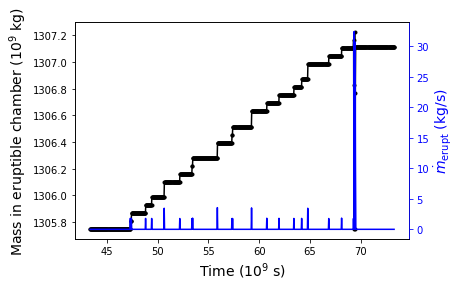

In [123]:
fig, ax_cycle = plt.subplots()

t_subset = t_vec[1300:2200]
m_subset = m_hist[1300:2200,-1]
ax_cycle.plot(t_subset /1e9, m_subset /1e9, 'k.-')
# ax_cycle.set_xlim(3e3, 3.1e3)
ax_cycle.set_xlabel("Time ($10^9$ s)", fontsize=14)
ax_cycle.set_ylabel("Mass in eruptible chamber ($10^9$ kg)", fontsize=14)

dmdt = np.diff(m_subset) / np.diff(t_subset)
t_vec_mid = 0.5 * (t_subset[1:] + t_subset[:-1])
dmdt_erupt = np.clip(dmdt, 0, None)

ax_cycle2 = ax_cycle.twinx()
line_handle, = ax_cycle2.plot(t_vec_mid/1e9, dmdt_erupt, 'b')
ax_cycle2.set_ylabel(r"$\dot{m}_\mathrm{erupt}$ (kg/s)", fontsize=14)

ax_cycle2.yaxis.label.set_color(line_handle.get_color())
ax_cycle2.spines["right"].set_edgecolor(line_handle.get_color())
ax_cycle2.tick_params(axis='y', colors=line_handle.get_color())

In [124]:
# Compute time series of total mass in
m_total = np.concatenate((m_hist.T, m_erupted_out[np.newaxis,:]), axis=0).sum(axis=0)
m_in_total = m_total - m_total[0]
# Compute extrusive / total
extrusive_ratio = np.zeros_like(m_in_total)
np.divide(m_erupted_out, m_in_total, where=m_in_total!=0, out=extrusive_ratio)

# As a variant to intrusive/extrusive: storage/eruption time series

# Plot mass records of each chamber
delta_m = m_hist.sum(axis=1) - m_hist.sum(axis=1)[0]

In [125]:
# Extract the conductivity of a single edge from matrix conductivity data
import scipy.spatial
dist_table = scipy.spatial.distance.cdist(np.stack((x_nodes, y_nodes, z_nodes), axis=1),
                             np.stack((x_nodes, y_nodes, z_nodes), axis=1))
Y_ref = np.max(Y_all.max(axis=0) * dist_table) / z_scale

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
C:\Users\Fredric\AppData\Local\Temp\ipykernel_10268\291938503.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("fig_network_viscoelasticQ.png", dpi=200)
C:\Users\Fredric\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


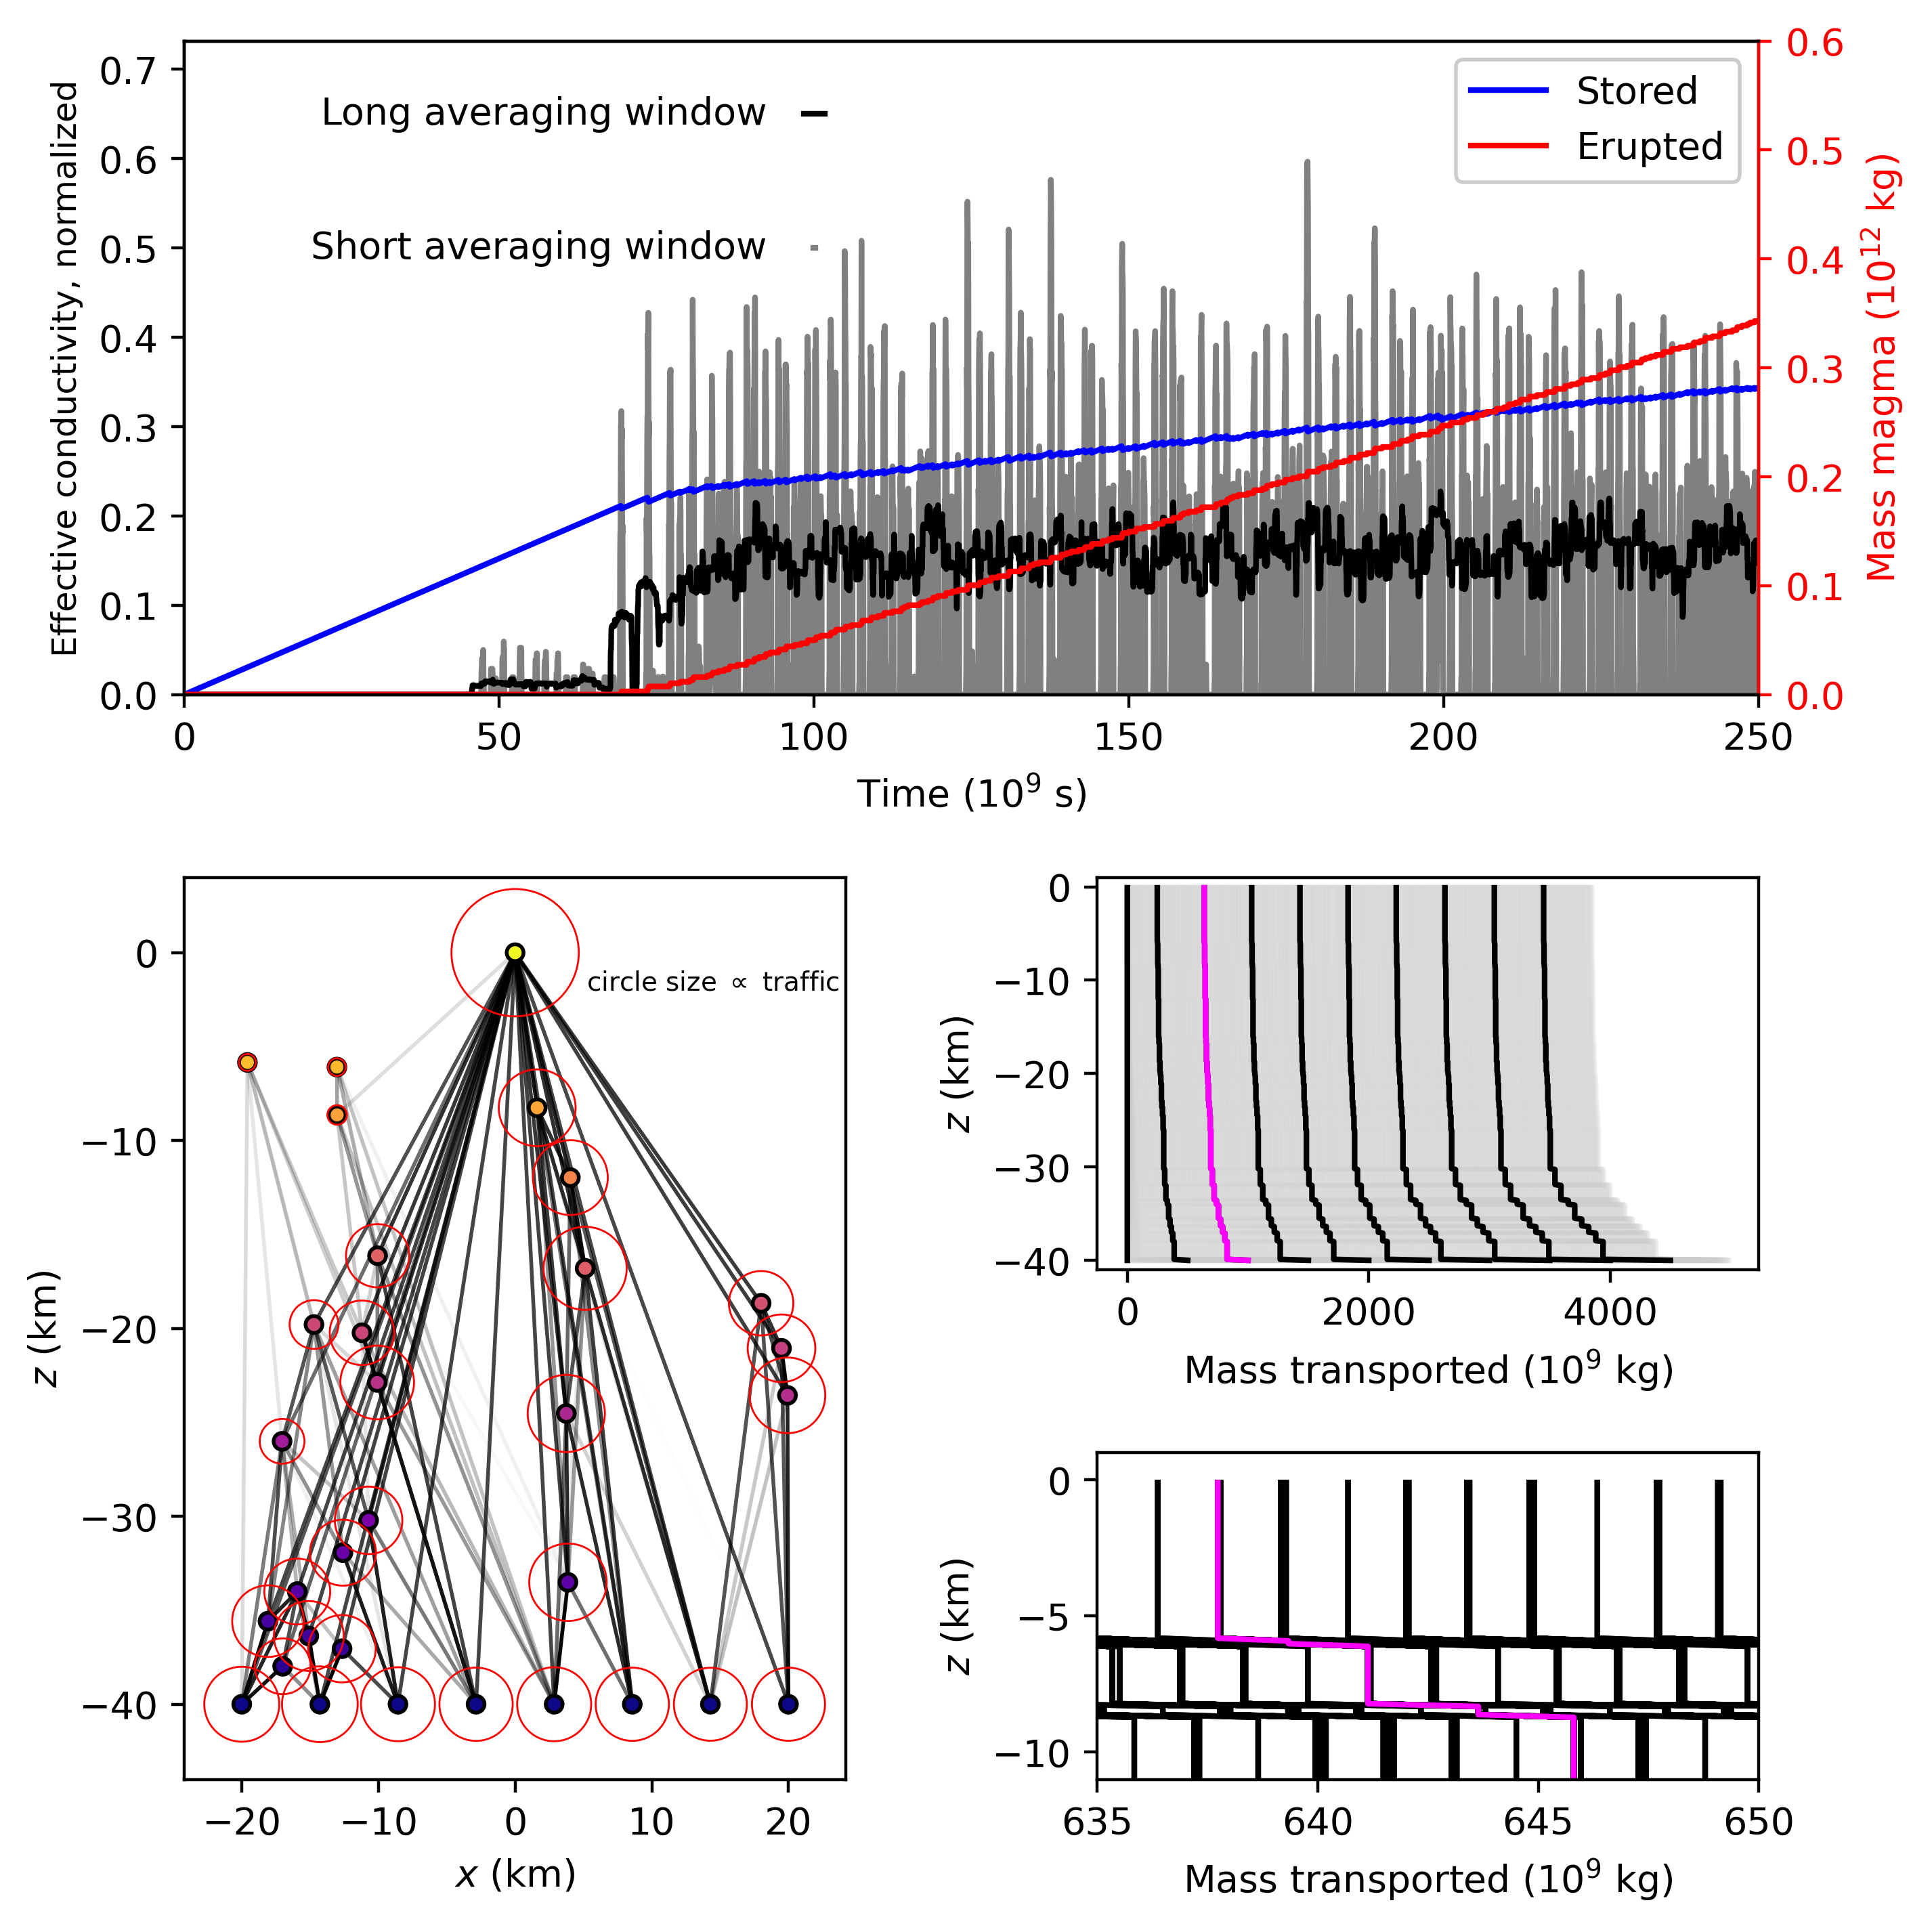

In [133]:
''' Combined summary figure '''

layout_type = 2

if layout_type == 1:
  layout = [
      ['B', 'A', 'A',],
      ['C', 'A', 'A',],
      ['D', 'E', 'F',],
  ]
  height_ratios = [0.8, 0.8, 1]
elif layout_type == 2:
  layout = [
      ['A', 'A',],
      ['B', 'C',],
      ['B', 'E',],
  ]
  height_ratios = [2, 1.2, 1.0]

fig, axes = plt.subplot_mosaic(
  layout,
  figsize=(7.5, 8.5),
  gridspec_kw={
    'height_ratios': height_ratios,
    'wspace': 0.38,
    'hspace': 0.4,
  },
  dpi=400,
)

ax_main = axes["A"]
ax_net = axes["B"]
ax_contours = axes["C"]
# ax_traffic = axes["D"]
ax_zoomcontours = axes["E"]

''' Conductivity time series plot '''
n, dt_window_10, t_avg_range_10, effective_cond_10 = connectivity_output[1]
n, dt_window_100, t_avg_range_100, effective_cond_100 = connectivity_output[2]
seconds_per_year = 365 * 24 * 3600
# Set flag to use physical units (else divide by single-edge conductivity)
use_absolute_units = False
if use_absolute_units:
  ax_main.plot(t_avg_range_10 / 1e9, effective_cond_10 * seconds_per_year * 1e6, 'gray', zorder=-10)
  ax_main.plot(t_avg_range_100 / 1e9, effective_cond_100 * seconds_per_year * 1e6, 'k')
  ax_main.set_ylabel("Effective conductivity ((m/yr) / MPa)", fontsize=10)
else:
  ax_main.plot(t_avg_range_10 / 1e9, effective_cond_10 / Y_ref, 'gray', zorder=-10)
  ax_main.plot(t_avg_range_100 / 1e9, effective_cond_100 / Y_ref, 'k')
  ax_main.set_ylabel("Effective conductivity, normalized", fontsize=9)

ax_main.set_xlabel("Time ($10^9$ s)", fontsize=10)
ax_main.set_xlim(0, 250)
ax_main.set_ylim(bottom=0)

# Add window length indicators
anchor_x_10 = 100
anchor_y_10 = .5
ax_main.plot([anchor_x_10 - 0.5*dt_window_10/1e9,
              anchor_x_10 + 0.5*dt_window_10/1e9],
             [anchor_y_10, anchor_y_10], 'gray')
ax_main.annotate("Short averaging window",
                 [anchor_x_10-7.5, anchor_y_10],
                 ha="right", va="center")
anchor_x_100 = 100
anchor_y_100 = .65
ax_main.plot([anchor_x_100 - 0.5*dt_window_100/1e9,
              anchor_x_100 + 0.5*dt_window_100/1e9],
             [anchor_y_100, anchor_y_100], 'k')
ax_main.annotate("Long averaging window",
                 [anchor_x_100-7.5, anchor_y_100],
                 ha="right", va="center")

ax_main2 = ax_main.twinx()
# line_handle, = ax_main2.plot(t_vec / 1e9, extrusive_ratio, 'r')
line_handle, = ax_main2.plot(t_vec / 1e9, delta_m/1e12, 'b', label=r"Stored")
line_handle, = ax_main2.plot(t_vec / 1e9, m_erupted_out/1e12, 'r', label=r"Erupted")
ax_main2.set_ylabel(
  r"Mass magma ($10^{12}$ kg)",
  # r"$\dot{m}_\mathrm{out} / \dot{m}_\mathrm{in}$",
  fontsize=10,
  color="red")
ax_main2.set_ylim(0, 0.6)
ax_main2.legend(fontsize=10, loc="upper right", framealpha=1.0)

ax_main2.yaxis.label.set_color(line_handle.get_color())
ax_main2.spines["right"].set_edgecolor(line_handle.get_color())
ax_main2.tick_params(axis='y', colors=line_handle.get_color())

''' Network (graph) plot '''

nx.draw_networkx_edges(G, pos, edge_color=edge_colors, ax=ax_net)
nx.draw_networkx_nodes(G, pos,
  node_color=depth_colors,
  node_size=20,
  linewidths=1,
  edgecolors="k",
  ax=ax_net
)

nx.draw_networkx_nodes(G, pos,
  node_color=[0, 0, 0, 0],
  node_size=20 * (0 + np.sqrt(total_traffic / total_traffic.min())),
  edgecolors='red',
  linewidths=0.5,
  ax=ax_net
)

ax_net.annotate(r"circle size $\propto$ traffic", [5.2, -2], fontsize=7)

length_scaling = 1
ax_net.set_ylim(-(40+4)*length_scaling, (0+4)*length_scaling)
ax_net.set_xlabel("$x$ (km)")
ax_net.set_ylabel("$z$ (km)")
ax_net.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

''' Traffic-x panel '''
# ax_traffic.bar(x_nodes/1e3, total_traffic * dt / 1e12, color=depth_colors, alpha=0.7, width=2)
# ax_traffic.set_xlabel("$x$ (km)")
# ax_traffic.set_ylabel("Total mass traffic ($10^{12}$ kg)")


''' Mass travel contours '''

# length_scaling = 1

length_scaling = 1
# Plot dense contours, in light color
contourplot_handle = ax_contours.plot(m_cdfs[::200,:-1].T / 1e9,
                                      z_sample_mesh[:-1]/1e3,
                                      color=[0.8, 0.8, 0.8, 0.3])
# Highlight several contours
contourplot_handle = ax_contours.plot(m_cdfs[::6000,:-1].T / 1e9,
                                      z_sample_mesh[:-1]/1e3,
                                      color='k')
contourplot_handle = ax_contours.plot(m_cdfs[12000,:-1].T / 1e9,
                                      z_sample_mesh[:-1]/1e3,
                                      color='magenta')
# contourplot_handle = ax_contours.plot(m_cumulative[1300:2200:,:-1].T / 1e9, z_sample_mesh[:-1]/1e3, 'k')
# contourplot_handle = ax_contours.contourf(
#   *np.meshgrid(t_vec[0::200] / 1e9,
#                z_sample_mesh[:-1]/1e3,
#   ),
#   m_cdfs[0::200,:-1].T / 1e9, levels=200)
# plt.xlim(51000,53000)

# ax_contours.set_xlim(0, 20)
ax_contours.set_ylim(-(40+1)*length_scaling, (0+1)*length_scaling)
ax_contours.set_xlabel("Mass transported ($10^{9}$ kg)")
ax_contours.set_ylabel("$z$ (km)")

plot_handle = ax_zoomcontours.plot(m_cdfs[11000:13000:,:-1].T / 1e9,
                                   z_sample_mesh[:-1]/1e3, 'k')
plot_handle = ax_zoomcontours.plot(m_cdfs[12000,:-1].T / 1e9,
                                   z_sample_mesh[:-1]/1e3, 'magenta')
ax_zoomcontours.set_xlim(635,650)
# ax_zoomcontours.set_xlim(1010, 1020)
ax_zoomcontours.set_ylim(-(10+1)*length_scaling, (0+1)*length_scaling)
ax_zoomcontours.set_xlabel("Mass transported ($10^9$ kg)")
ax_zoomcontours.set_ylabel("$z$ (km)")
# Highlight one contour


# t_subset = t_vec[1300:2200]
# m_subset = m_hist[1300:2200,-1]
# ax_cycle.plot(t_subset /1e9, m_subset /1e9, 'k.-')
# # ax_cycle.set_xlim(3e3, 3.1e3)
# ax_cycle.set_xlim(770, 840)
# ax_cycle.set_xlabel("Time ($10^9$ s)", fontsize=12)
# ax_cycle.set_ylabel("Eruptible chamber $m$ ($10^9$ kg)", fontsize=10)

# dmdt = np.diff(m_subset) / np.diff(t_subset)
# t_vec_mid = 0.5 * (t_subset[1:] + t_subset[:-1])
# dmdt_erupt = np.clip(dmdt, 0, None)

# ax_cycle2 = ax_cycle.twinx()
# line_handle, = ax_cycle2.plot(t_vec_mid/1e9, dmdt_erupt, 'b')
# ax_cycle2.set_ylabel(r"$\dot{m}_\mathrm{erupt}$ (kg/s)", fontsize=10)

# ax_cycle2.yaxis.label.set_color(line_handle.get_color())
# ax_cycle2.spines["right"].set_edgecolor(line_handle.get_color())
# ax_cycle2.tick_params(axis='y', colors=line_handle.get_color())

fig.set_tight_layout(True)

plt.savefig("fig_network_viscoelasticQ.png", dpi=200)
# plt.savefig("fig_network_viscoelasticQ.eps")
# plt.savefig("fig_network_viscoelasticQ.pdf")

plt.show();

#### Particle co-simulation

In [134]:
N_particles_per_node = 1000
n_nodes = len(global_sys.nodes)
N_particles = N_particles_per_node * n_nodes

inverse_mass = scipy.sparse.diags([1/node.m0 for node in global_sys.nodes])

start_node = np.full((N_particles,), 0, dtype=int)
for i in range(n_nodes):
  start_node[i*N_particles_per_node:(i+1)*N_particles_per_node] = i
curr_node = start_node.copy()
# Allocate node location history for each particle
node_location = np.full((t_vec.size, N_particles), -1, dtype=int) 
# Fill initial
node_location[0,:] = 0

NTMAX = 60000

avg_turnover_rates = np.zeros((n_nodes+1, n_nodes+1))
num_steps_taken = 0

for i, t in enumerate(t_vec[1:NTMAX]):
  # Load q, pressure from ODE solution
  q = q_out[i,...]

  p_node = global_sys.pressure(q)

  # Compute turnover rates (mdot / m) with virtual node for erupted
  turnover_rates = np.zeros((n_nodes+1, n_nodes+1))
  turnover_rates[:n_nodes, :n_nodes] = inverse_mass @ global_sys.mass_rates(q)
  # Eruption from last node
  turnover_rates[n_nodes, n_nodes-1] = \
    (m_erupted_out[i] - m_erupted_out[i-1]) / global_sys.nodes[-1].m0 / (t_vec[i] - t_vec[i-1])
  # Compute instantaneous Poisson rates from total out rate from node j
  poisson_lambda = np.array(turnover_rates.sum(axis=0)).squeeze()
  # Probability of escaping from node j to node i given that particle escapes
  path_probability = np.zeros(turnover_rates.shape)
  np.divide(turnover_rates, poisson_lambda, where=poisson_lambda!=0, out=path_probability)
  # Probability of exiting in current timestep
  prob = poisson_lambda[curr_node] * (t_vec[i] - t_vec[i-1])

  # Record path probabilities
  avg_turnover_rates += turnover_rates
  num_steps_taken += 1

  # # End walk at last node
  # prob[-1] = 0

  # Determine whether each particle exits node
  exit_roll = np.random.rand(N_particles) < prob
  # Choose exit path based on probability
  new_node = (np.random.rand(N_particles)[np.newaxis,:]
              < np.cumsum(path_probability[:,curr_node], axis=0)).argmax(axis=0)
  # Move all particles
  curr_node = np.where(exit_roll, new_node, curr_node)
  # Save particle location
  node_location[i+1,:] = curr_node

avg_turnover_rates /= num_steps_taken

In [135]:
# Stride over time index, 
node_loc_conditional = node_location[::1000,]

z_particles = np.zeros_like(node_loc_conditional)
z_nodes_aug = np.array([*z_nodes, 0.0])
z_particles.ravel()[:] = z_nodes_aug[node_loc_conditional.ravel()]
# plt.plot(z_particles[500-1,:], 'o')
# plt.plot(z_particles[1000-1,:], '.')

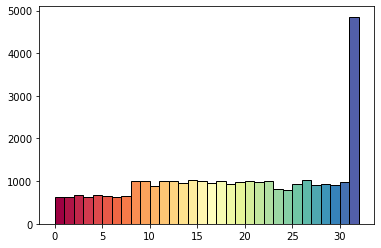

In [136]:
i = -1
data = node_loc_conditional[i,:]
n, bins, patches = plt.hist(data,
                            bins=np.arange(33), edgecolor='black')

bar_colors =  matplotlib.cm.Spectral( # hsv
  np.linspace(0,1,global_sys.num_blocks,endpoint=False))

for patch, color in zip(patches, bar_colors):
  patch.set_facecolor(color)


In [137]:
# Vector representing location at timestep
current_loc = node_loc_conditional[i,:]
# Vector representing origin of corresponding particle
origin = np.tile(np.arange(32), (1000,1)).T.ravel()

# Matrix tabulating contents of each node
# Each row i is a chamber, containing count of particles originating from j
contents = np.zeros((n_nodes+1, n_nodes+1))
contents[current_loc, origin] += 1
for (i, j) in zip(current_loc, origin):
  contents[i,j] += 1

In [138]:
import matplotlib.patches

fig, ax = plt.subplots()
ax.set_axis_off()
for (x, z, row) in zip(x_nodes, z_nodes, contents[:-1]):
  # Fixed size inset axes
  inset_ax = ax.inset_axes([x/1e3, z/1e3, 3, 3], transform=ax.transData)
  inset_ax.pie([1,], colors=[[0, 0, 0]], radius=1.1)
  inset_ax.pie(row, colors=bar_colors, radius=1.0)

bounding_box = matplotlib.patches.Rectangle(
    (0.0, 0.0),        # Starting coordinates (bottom-left corner)
    40.0, 40.0,          # Width and height of the box
    edgecolor='black',  # Border color
    facecolor='none',  # Interior color ('none' makes it transparent)
    linewidth=3        # Border thickness
)

plt.savefig("lagrangian_viscoelastic_origin_piecharts.png", dpi=100)
plt.savefig("lagrangian_viscoelastic_origin_piecharts.svg")
plt.savefig("lagrangian_viscoelastic_origin_piecharts.eps")

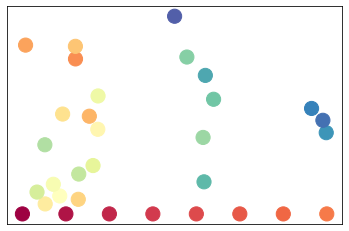

In [139]:
nx.draw_networkx_nodes(G, pos,
                node_size=node_size,
                node_color=bar_colors,)

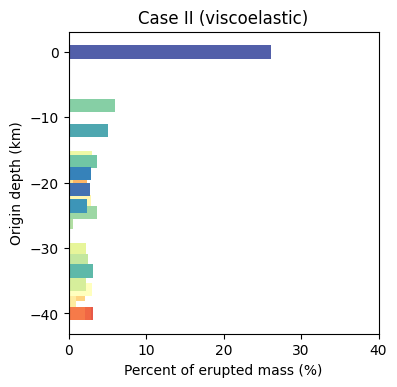

In [143]:
# Histogram of erupted particles

# Row representing count of erupted particles indexed by the source chamber
erupted_source = contents[-1,:-1]

plt.subplots(figsize=(4,4), dpi=100)

plt.barh(z_nodes/1e3, 100*erupted_source/erupted_source.sum(),
         color=bar_colors, height=2)
plt.xlabel("Percent of erupted mass (%)")
plt.ylabel("Origin depth (km)")
plt.xlim(0, 40)

plt.title("Case II (viscoelastic)")

plt.savefig("lagrangian_viscoelastic_origin_erupted.png", dpi=100)
plt.savefig("lagrangian_viscoelastic_origin_erupted.svg")
plt.savefig("lagrangian_viscoelastic_origin_erupted.eps")